<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/01_introduction/06_seaborn_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎨 A First Look at Seaborn

> **Track:** Introduction Session — **bonus notebook** (optional) · **Estimated time:** ~10 min · **Difficulty:** complete beginner

Notebook 5 finished with a chart: eight lines of matplotlib, and it said exactly what we wanted it to say. This short bonus notebook shows you the *other* way to draw it — with **seaborn**, a library that sits on top of matplotlib and, crucially, **speaks DataFrame**.

The bargain is simple. You hand seaborn a table and the *names* of the columns you want on each axis, and it does the rest: the drawing, the colours, a first draft of the labels, and the legend. One line instead of five. In exchange you give up some fine control over the details — which is why the two libraries are partners rather than rivals.

> ℹ️ **This notebook stands on its own.** It rebuilds the countries table from Notebook 5, so you can run it during the session if there is time, or on your own afterwards.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Say in one sentence what **seaborn** adds to matplotlib, and import it the way everybody does: `import seaborn as sns`.
2. Draw a bar chart and a scatter plot straight from a DataFrame by **naming columns** — `sns.barplot(data=df, x=..., y=...)`.
3. Use **`hue=`** to colour by a category and get the legend for free.
4. Explain why a seaborn chart that quietly **averages** your data deserves a second look.

## 1. What seaborn is

**matplotlib**, which you met in Notebook 5, is the engine. It can draw anything, but you have to tell it everything: which values, which colours, which labels. **seaborn** is a layer built on top of that engine for one particular job — **charting data that already lives in a DataFrame.**

Two differences do most of the work:

- **It takes column names, not lists of values.** `sns.barplot(data=df, x="col_a", y="col_b")`: you point at the table and name the columns. Nothing to pull out by hand first.
- **It has opinions.** Coordinated colours, readable defaults, axis labels borrowed from the column names, a legend whenever one is needed. The chart arrives looking half-finished rather than raw.

And because seaborn draws *onto* an ordinary matplotlib figure, everything from Notebook 5 still works: `plt.title(...)`, `plt.xlabel(...)`, `plt.tight_layout()` and `plt.show()` behave exactly as they did.

In [1]:
import io

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   # "sns" is the traditional nickname — everyone writes this

# The same twelve countries as Notebook 5, rebuilt so this notebook runs on its own.
csv_text = """country,continent,population_millions,internet_users_pct,ai_startups_per_million
Germany,Europe,84.5,93.0,8.2
France,Europe,68.2,92.0,7.5
Estonia,Europe,1.4,92.0,15.0
United States,Americas,335.0,92.0,18.5
Canada,Americas,39.0,94.0,12.4
Brazil,Americas,216.0,84.0,2.1
India,Asia,1430.0,52.0,1.2
Japan,Asia,124.0,84.0,3.8
South Korea,Asia,51.7,97.0,9.6
Nigeria,Africa,224.0,42.0,0.4
Kenya,Africa,55.1,40.0,0.9
South Africa,Africa,60.4,72.0,1.5
"""

df = pd.read_csv(io.StringIO(csv_text))

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE   = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_PURPLE]

# One line, and every seaborn chart below inherits this look.
sns.set_theme(style="whitegrid", palette=BAS_PALETTE)
# ---------------------------------------------------------------------------

print(f"seaborn version: {sns.__version__}")
df.head(3)

seaborn version: 0.13.2


,country,continent,population_millions,internet_users_pct,ai_startups_per_million
0,Germany,Europe,84.5,93.0,8.2
1,France,Europe,68.2,92.0,7.5
2,Estonia,Europe,1.4,92.0,15.0


> 🎨 The colours are the Bridging AI & Society summer-school palette again, so these charts match the ones in Notebook 5. `sns.set_theme(...)` is the seaborn habit worth copying: call it once at the top, and every chart in the notebook is styled consistently — no repetition.

## 2. The same chart, one line

At the end of Notebook 5 we charted **AI startup density**: sort the table, pull out two columns, call `plt.barh`, label everything. Here is that chart again, in seaborn.

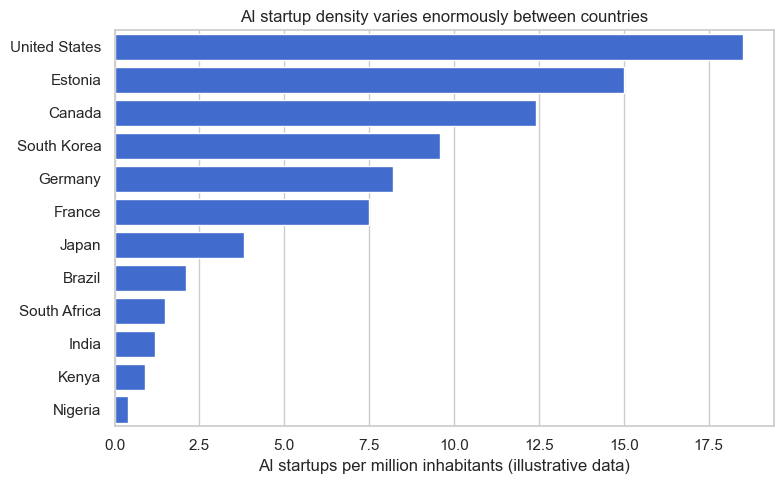

In [2]:
# The order we want the bars in: highest density at the top
country_order = df.sort_values("ai_startups_per_million", ascending=False)["country"]

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="ai_startups_per_million", y="country",
            order=country_order, color=BAS_BLUE, saturation=1)
plt.title("AI startup density varies enormously between countries")
plt.xlabel("AI startups per million inhabitants (illustrative data)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**What just happened.** One call — `data=df` plus two column names — and seaborn worked out the rest. The bars run horizontally because the *text* column is on `y` and the *number* column on `x`; swap them and the same call gives you vertical bars.

Three details worth naming:

- **`order=`** decides the sequence of the bars. Categories have no natural order, so if you don't sort them, your reader has to do it by eye. Sorted bars are a courtesy, not decoration.
- **`color=BAS_BLUE`** paints every bar the same, because they are twelve measurements of *one* thing; twelve colours would imply twelve different meanings. `saturation=1` is there because seaborn softens bar colours slightly by default — we want our exact brand blue.
- **The labels.** Seaborn had already written `ai_startups_per_million` on the axis, taken from the column name — genuinely useful while you explore, and not good enough for anybody else. So we overwrote it, and blanked the y-label because "Country" above a column of country names tells nobody anything.

Compare with Notebook 5: matplotlib needed a sorted *copy* of the table and both columns handed to it by hand. Seaborn needed the table and three column names. That gap is the whole point of the library.

## 3. The payoff: colour by category with `hue=`

Shorter bar charts are not really why people reach for seaborn. **`hue=`** is. Name a categorical column, and seaborn splits the data by it, assigns a colour to each group, and writes the legend — the three steps everybody used to do by hand, and the third of which everybody used to forget.

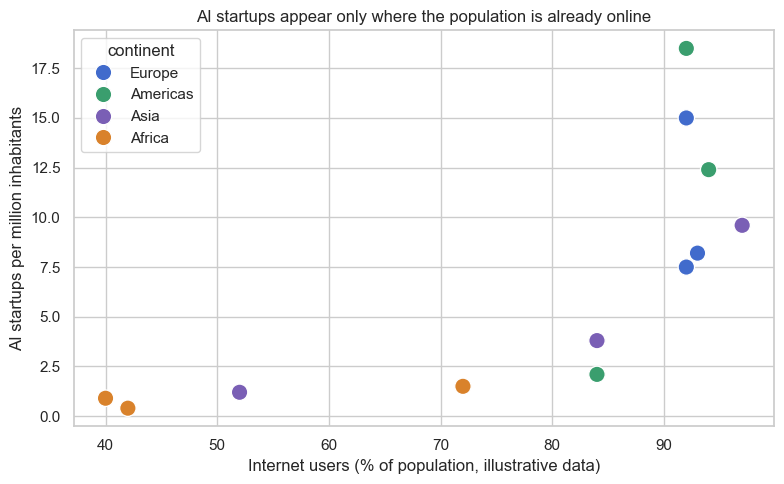

In [3]:
CONTINENT_COLOURS = {          # our own colours, so the meaning is ours to choose
    "Africa"  : BAS_AMBER,
    "Americas": BAS_GREEN,
    "Asia"    : BAS_PURPLE,
    "Europe"  : BAS_BLUE,
}

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="internet_users_pct", y="ai_startups_per_million",
                hue="continent", palette=CONTINENT_COLOURS, s=140)
plt.title("AI startups appear only where the population is already online")
plt.xlabel("Internet users (% of population, illustrative data)")
plt.ylabel("AI startups per million inhabitants")
plt.tight_layout()
plt.show()

**Reading it**, with the three moves from Notebook 5 — axes, shape, surprises:

1. **Axes.** Two *relative* measures: a percentage of a population, and a count per million people. Neither depends on how big the country is, which is what makes twelve very different countries comparable at all.
2. **Shape.** Squint, and there is a floor: every country below roughly 90% online sits under 4 startups per million. Above 90% the points fan out across the entire height of the chart, from 7.5 to 18.5. Connectivity looks like a *precondition* — it seems to decide whether a country appears on this chart at all, and almost nothing about how high it gets.
3. **Surprises.** Estonia, at 1.4 million inhabitants, sits at the top; the two most populous countries in the table sit at the very bottom left. And the colours turn out to matter: the continents cluster, which is a fact about wealth and infrastructure long before it is a fact about AI.

In matplotlib this chart would be a loop over the four continents, four `scatter` calls, a colour argument each, and a `legend()` call at the end. `hue="continent"` replaced all of it.

> ⚠️ **Twelve points are not evidence.** A pattern in twelve illustrative rows is a *hypothesis* — something to go and check on real data, not a finding to quote.

## 4. Seaborn will do the `groupby` for you — and that is worth knowing

In Notebook 5 you computed average internet access per continent with `groupby`, and got four numbers. Hand seaborn a *text* column and a *number* column and it will do that arithmetic itself, without being asked.

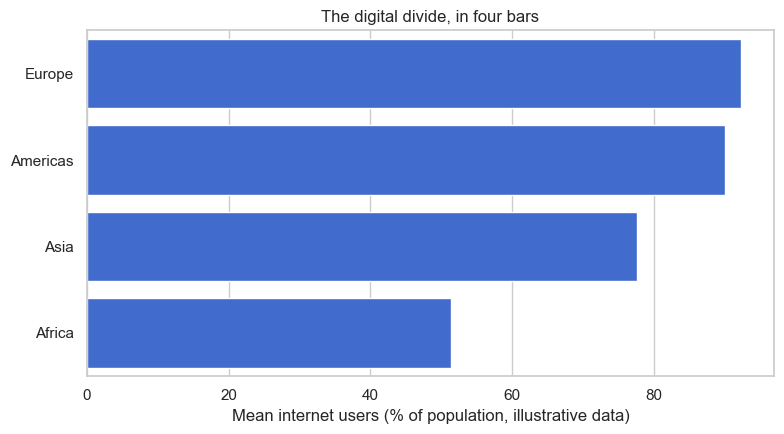

In [4]:
# Sort the continents by their mean, so the bars are in a meaningful order
continent_order = (df.groupby("continent")["internet_users_pct"]
                     .mean()
                     .sort_values(ascending=False)
                     .index)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=df, x="internet_users_pct", y="continent",
            order=continent_order, color=BAS_BLUE, errorbar=None, saturation=1)
plt.title("The digital divide, in four bars")
plt.xlabel("Mean internet users (% of population, illustrative data)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Notice what we never asked for.** There are twelve countries in `df` and four bars on the chart, so *something* combined them: each bar is the **mean** of the countries on that continent — the same four numbers `groupby` printed in Notebook 5, drawn instead of listed. We wrote no aggregation at all; seaborn's default for "a category against a number" is to average.

That convenience is also the one thing to be careful about. A bar says nothing about how many rows it came from or how much they disagreed: our African bar averages **three** countries whose internet access runs from 40% to 72%, and shows a single 51%. By default seaborn adds a thin whisker to each bar to hint at that uncertainty — with three rows per group it is more suggestion than statistic, so we removed it with `errorbar=None` rather than let it imply a precision we do not have.

Either choice is defensible. The habit that matters is this: **when a chart turns categories into numbers, ask what arithmetic it did.** Usually it is a mean, and a mean always hides its spread.

### 🎯 Try it (1–2 min) — One more chart, your way

Draw a bar chart of **internet access per country** — the chart you built by hand at the end of Notebook 5, now in seaborn. Start from the `sns.barplot` cell in section 2 and change three things: the column name, the sort order, and the words on the chart.

In [5]:
# Your turn 👇


<details><summary>💡 Click to reveal the solution</summary>

```python
order = df.sort_values("internet_users_pct", ascending=False)["country"]

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="internet_users_pct", y="country",
            order=order, color=BAS_AMBER, saturation=1)
plt.title("Internet access ranges from 40% to 97% across our sample")
plt.xlabel("Internet users (% of population, illustrative data)")
plt.ylabel("")
plt.tight_layout()
plt.show()
```

The recipe never changed — only the column name (twice) and the words. `BAS_AMBER` marks it as a different measurement from the blue chart above, exactly as in Notebook 5.

Then read it: South Korea tops out at 97%, Kenya and Nigeria sit near 40%, and the gap in the middle is the same digital divide the four-bar chart summarised — one bar per country instead of one per continent. Worth comparing with the matplotlib version in Notebook 5 side by side: same picture, a few lines shorter, and no sorted helper table, because `order=` did the sorting where it was needed.

</details>

### 💬 Discuss (30 seconds, with your neighbour)

Good defaults make it easy to publish a chart you never really thought about: an average appears without being requested, and the library — not you — decides which colour means which group. Where else do you meet that trade of convenience for control in the tools you use? And when a chart is technically correct but still misleading, who is responsible: the tool, or the person who published it?

## 5. So — matplotlib or seaborn?

Wrong question, in a way. Every seaborn chart *is* a matplotlib chart; you just did not have to assemble it.

| Reach for… | When |
|---|---|
| **seaborn** | your data is in a DataFrame and you want a standard statistical chart quickly — bars, scatter, distributions, one colour per category |
| **matplotlib** | you need control over each element: an unusual chart, several panels, exact colours, annotations pointing at particular values |
| **both** | almost always. Seaborn draws it, matplotlib labels and adjusts it — every chart above did exactly that |

Which is why the self-paced track teaches both, in that order: matplotlib first, so nothing is magic, then seaborn properly.

## 🧠 Key takeaways

1. **seaborn is matplotlib with DataFrame manners.** `import seaborn as sns`, then `sns.set_theme(...)` once at the top to style everything that follows.
2. You **name columns**, you don't hand over values: `sns.barplot(data=df, x="a", y="b")`. Text on `y` gives horizontal bars, text on `x` vertical ones.
3. **`hue="category"`** colours by group *and* writes the legend — the single biggest time-saver in the library.
4. **`order=`** sorts a categorical chart. Unsorted bars make the reader do work you could have done for them.
5. Seaborn's automatic axis labels come from column names: perfect while exploring, never good enough to publish. Overwrite them with `plt.xlabel` / `plt.title`.
6. A category-against-number chart **aggregates** — usually the mean. Know which number you are showing, and what it hides.

## ✅ Self-assessment

- [ ] I can import seaborn and set a consistent look for a whole notebook in one line.
- [ ] I can draw a bar chart and a scatter plot from a DataFrame by naming columns.
- [ ] I can colour a chart by a category with `hue=` and say what the legend is telling me.
- [ ] I can explain what a seaborn bar chart does silently when it meets a text column — and why I should check.
- [ ] I can name a situation where I would reach for plain matplotlib instead.

## 🚀 Where to go from here

That really is the end of the introduction session — **congratulations! 🎉** You have loaded a table, questioned it, computed a new column, grouped it, and charted it two different ways.

Both plotting libraries get a full notebook of their own in the self-paced **[`../02_advanced_self_learning/`](../02_advanced_self_learning/)** track, and they are meant to be read in this order:

- [`../02_advanced_self_learning/09_visualization_matplotlib.ipynb`](../02_advanced_self_learning/09_visualization_matplotlib.ipynb) — **matplotlib in depth**: the Figure/Axes model, one chart type per question, multi-panel dashboards, and how charts mislead.
- [`../02_advanced_self_learning/10_visualization_seaborn.ipynb`](../02_advanced_self_learning/10_visualization_seaborn.ipynb) — **seaborn in depth**: long vs wide data, the figure-level plots, distributions, `hue`/`col`/`row` faceting, regression plots, heatmaps and palettes that survive colour blindness.

Or start the track at the beginning: [`../02_advanced_self_learning/01_python_basics.ipynb`](../02_advanced_self_learning/01_python_basics.ipynb).